# **HOSPITAL_SLA ANALYSIS**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('hospital_data.csv')
df.head()

,Patient_ID,Arrival_Time,Doctor_Seen_Time,Department,Severity,Wait_Time_Min
0,1,2026-01-12 23:45:15,2026-01-12 23:58:15,Radiology,Critical,13.30
1,2,2026-01-07 01:23:56,2026-01-07 01:35:56,Radiology,Urgent,11.98
2,3,2026-01-27 19:46:38,2026-01-27 20:04:38,Lab,Urgent,17.53
3,4,2026-01-10 22:19:46,2026-01-10 22:36:46,OPD,Normal,16.52
4,5,2026-02-03 09:07:26,2026-02-03 09:39:26,Radiology,Critical,31.57


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient_ID        2000 non-null   int64  
 1   Arrival_Time      2000 non-null   object 
 2   Doctor_Seen_Time  2000 non-null   object 
 3   Department        2000 non-null   object 
 4   Severity          2000 non-null   object 
 5   Wait_Time_Min     2000 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 93.9+ KB


In [ ]:
df.describe()

,Patient_ID,Wait_Time_Min
count,2000.000000,2000.000000
mean,1000.500000,19.749880
std,577.494589,8.672452
min,1.000000,5.040000
25%,500.750000,12.260000
50%,1000.500000,19.435000
75%,1500.250000,27.345000
max,2000.000000,34.990000


In [ ]:
display(df.isnull().sum())
print()
print(df.duplicated().sum())

,0
Patient_ID,0
Arrival_Time,0
Doctor_Seen_Time,0
Department,0
Severity,0
Wait_Time_Min,0



0


In [ ]:
df['Arrival_Hour']=pd.to_datetime(df['Arrival_Time']).dt.hour
df.head()

,Patient_ID,Arrival_Time,Doctor_Seen_Time,Department,Severity,Wait_Time_Min,Arrival_Hour
0,1,2026-01-12 23:45:15,2026-01-12 23:58:15,Radiology,Critical,13.30,23
1,2,2026-01-07 01:23:56,2026-01-07 01:35:56,Radiology,Urgent,11.98,1
2,3,2026-01-27 19:46:38,2026-01-27 20:04:38,Lab,Urgent,17.53,19
3,4,2026-01-10 22:19:46,2026-01-10 22:36:46,OPD,Normal,16.52,22
4,5,2026-02-03 09:07:26,2026-02-03 09:39:26,Radiology,Critical,31.57,9


In [ ]:
df['SLA_Status'] = df['Wait_Time_Min'].apply(lambda x: 'On Time' if x <= 20 else 'Delayed')
df.head()

,Patient_ID,Arrival_Time,Doctor_Seen_Time,Department,Severity,Wait_Time_Min,Arrival_Hour,SLA_Status
0,1,2026-01-12 23:45:15,2026-01-12 23:58:15,Radiology,Critical,13.30,23,On Time
1,2,2026-01-07 01:23:56,2026-01-07 01:35:56,Radiology,Urgent,11.98,1,On Time
2,3,2026-01-27 19:46:38,2026-01-27 20:04:38,Lab,Urgent,17.53,19,On Time
3,4,2026-01-10 22:19:46,2026-01-10 22:36:46,OPD,Normal,16.52,22,On Time
4,5,2026-02-03 09:07:26,2026-02-03 09:39:26,Radiology,Critical,31.57,9,Delayed


In [ ]:
display(df['SLA_Status'].value_counts(normalize=True)*100)

,proportion
SLA_Status,
On Time,51.6
Delayed,48.4


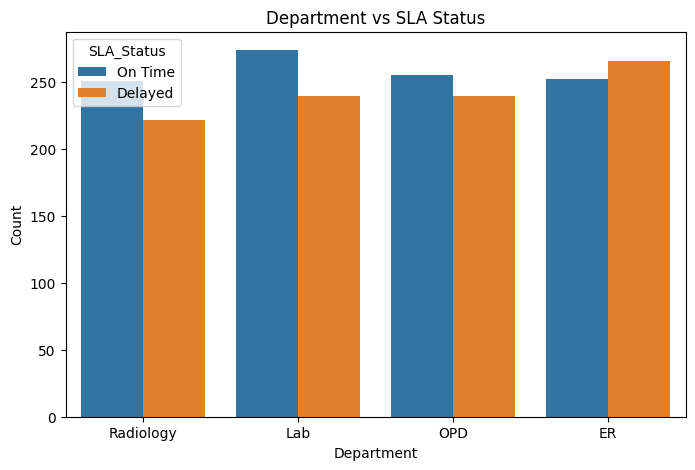

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x=df['Department'],hue=df['SLA_Status'])
plt.title('Department vs SLA Status')
plt.xlabel('Department')
plt.ylabel('Count')
plt.show()

,Wait_Time_Min
Severity,
Critical,19.851439
Normal,19.816342
Urgent,19.584654



------------------------------------------------------------


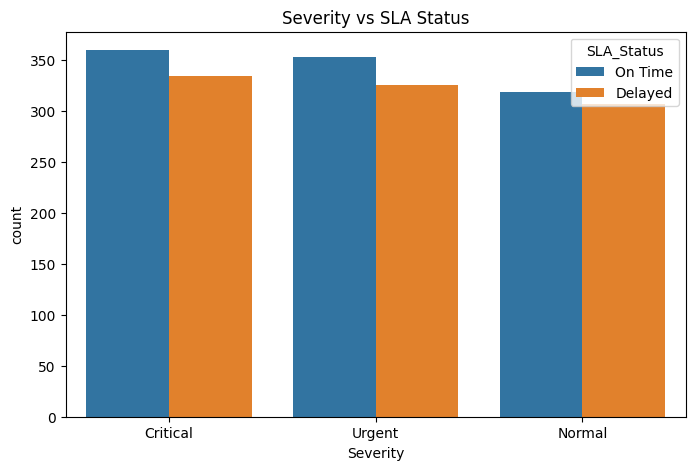

In [ ]:
display(df.groupby('Severity')['Wait_Time_Min'].mean())
print()
print("-"*60)
plt.figure(figsize=(8,5))
sns.countplot(data=df,x=df['Severity'],hue=df['SLA_Status'])
plt.title('Severity vs SLA Status')
plt.xlabel('Severity')
plt.show()

# How many patients arrived in each hour

In [ ]:
display(df['Arrival_Hour'].value_counts().sort_values(ascending=False))

,count
Arrival_Hour,
8,99
16,97
23,92
20,92
17,90
12,90
2,89
0,89
22,87


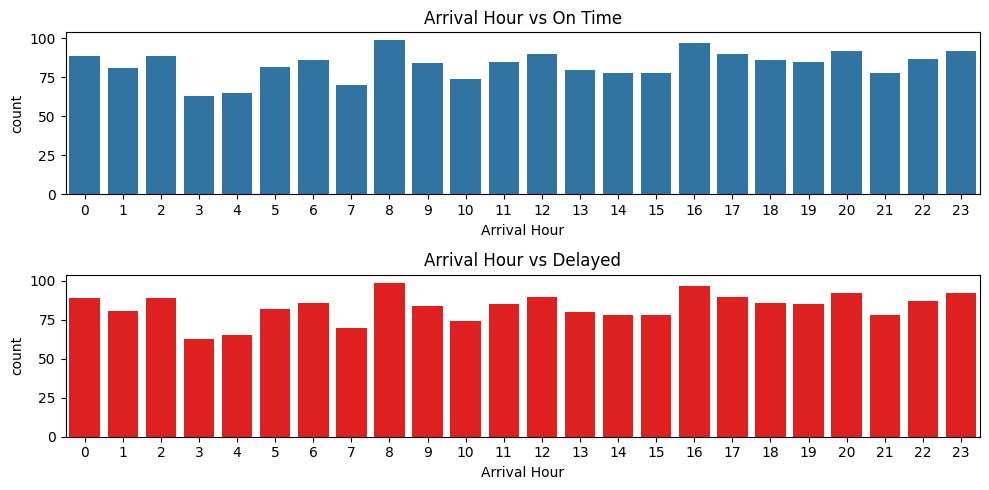

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
sns.countplot(data=df[df['SLA_Status']=='On Time'],x=df['Arrival_Hour'])
plt.title('Arrival Hour vs On Time')
plt.xlabel('Arrival Hour')
plt.subplot(2,1,2)
sns.countplot(data=df[df['SLA_Status']=='Delayed'],x=df['Arrival_Hour'],color='red')
plt.title("Arrival Hour vs Delayed")
plt.xlabel("Arrival Hour")
plt.tight_layout()
plt.show()

In [ ]:
print('='*70)
print("                   KEY INSIGHTS")
print('='*70)

total_patients = len(df)

on_time_pct = (df['SLA_Status'] == 'On Time').mean() * 100
delayed_pct = (df['SLA_Status'] == 'Delayed').mean() * 100

avg_wait = df['Wait_Time_Min'].mean()

# Department with highest average waiting time
dept_avg_wait = df.groupby('Department')['Wait_Time_Min'].mean()
worst_dept = dept_avg_wait.idxmax()
worst_dept_wait = dept_avg_wait.max()

# Department with best SLA compliance
dept_sla = (
    df.groupby('Department')['SLA_Status']
    .apply(lambda x: (x == 'On Time').mean() * 100)
)

best_dept = dept_sla.idxmax()
best_dept_sla = dept_sla.max()

# Severity with highest average waiting time
severity_avg_wait = df.groupby('Severity')['Wait_Time_Min'].mean()
worst_severity = severity_avg_wait.idxmax()
worst_severity_wait = severity_avg_wait.max()

# Busiest arrival hour
busiest_hour = df['Arrival_Hour'].value_counts().idxmax()
busiest_hour_patients = df['Arrival_Hour'].value_counts().max()

# Hour with highest delayed percentage
hourly_delay = (
    df.groupby('Arrival_Hour')['SLA_Status']
    .apply(lambda x: (x == 'Delayed').mean() * 100)
)

worst_hour = hourly_delay.idxmax()
worst_hour_delay = hourly_delay.max()

print(f"\n1. Total patients analyzed: {total_patients:,}")

print(
    f"\n2. Overall SLA Performance: "
    f"{on_time_pct:.2f}% of patients were seen within the 20-minute SLA target, "
    f"while {delayed_pct:.2f}% experienced delays."
)

print(
    f"\n3. The overall average patient waiting time was "
    f"{avg_wait:.2f} minutes."
)

print(
    f"\n4. {worst_dept} had the highest average waiting time "
    f"at {worst_dept_wait:.2f} minutes, indicating a potential area for improvement."
)

print(
    f"\n5. {best_dept} showed the best SLA performance, "
    f"with {best_dept_sla:.2f}% of patients being seen on time."
)

print(
    f"\n6. {worst_severity} patients had the highest average waiting time "
    f"at {worst_severity_wait:.2f} minutes."
)

print(
    f"\n7. The busiest arrival hour was {busiest_hour}:00, "
    f"with {busiest_hour_patients} patient arrivals."
)

print(
    f"\n8. The highest delay rate occurred at {worst_hour}:00, "
    f"where {worst_hour_delay:.2f}% of patients exceeded the SLA target."
)

                   KEY INSIGHTS

1. Total patients analyzed: 2,000

2. Overall SLA Performance: 51.60% of patients were seen within the 20-minute SLA target, while 48.40% experienced delays.

3. The overall average patient waiting time was 19.75 minutes.

4. ER had the highest average waiting time at 20.18 minutes, indicating a potential area for improvement.

5. Lab showed the best SLA performance, with 53.31% of patients being seen on time.

6. Critical patients had the highest average waiting time at 19.85 minutes.

7. The busiest arrival hour was 8:00, with 99 patient arrivals.

8. The highest delay rate occurred at 19:00, where 54.12% of patients exceeded the SLA target.


In [ ]:
df.to_csv("cleaned_hospital_dataset.csv",index=False)